In [ ]:
#!pip install edfio
#for running on kaggle

In [ ]:
# Cell 0 — Config, imports, and run flags (self-contained; no external project files)
from __future__ import annotations

import json
import os
import re
import warnings
from dataclasses import dataclass, field
from io import StringIO
from typing import Dict, List, Optional, Tuple, Union

import edfio
import h5py
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import LeaveOneGroupOut, ParameterGrid
from tqdm import tqdm
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

"""
USE_PHYSIO_HANDCRAFTED takes a lot of time to run, set as False probably
RUN_SLEEPFM_PREP might not be useful if Emad alr takes care of it, set as False

"""

# --- Run mode ---
RUN_TABULAR = True       # demographics + CAISR -> feature_matrix.csv
USE_PHYSIO_HANDCRAFTED = False  # add 49 handcrafted physio features (7 lead groups x 7 stats)
RUN_XGB = True           # baseline on tabular features
RUN_SLEEPFM_PREP = False    # write SleepFM-ready HDF5 files
EXPLORE_PHYSIO = False   # channel catalog demo at end
VERBOSE = True

# --- Performance ---
SKIP_IF_FEATURE_CSV_EXISTS = True  # set False after changing SAMPLE_FRACTION so features are re-extracted

# --- Cohort sampling (for fast iteration) ---
SAMPLE_MODE = "fraction"   # "all" | "fraction" | "site" | "n_patients"
SAMPLE_FRACTION = 1     # used when SAMPLE_MODE == "fraction"
SAMPLE_SITE = "S0001"      # used when SAMPLE_MODE == "site"
SAMPLE_N = 50              # used when SAMPLE_MODE == "n_patients"
SAMPLE_STRATIFY = True     # preserve CI class balance
SAMPLE_SEED = 42

# --- Validation / tuning ---
N_SPLITS = 5
DO_XGB_TUNING = True
TUNING_MODE = "light"

# --- Paths ---
DATA_FOLDER_CANDIDATES = [
    "/kaggle/input/physionetchallenge2026data/versions/7",

]
OUTPUT_DIR = "/kaggle/working"
SLEEPFM_HDF5_DIR = os.path.join(OUTPUT_DIR, "sleepfm_hdf5")
DEMOGRAPHICS_FILE = "demographics.csv"
ALGO_SUBFOLDER = "algorithmic_annotations"
PHYSIO_SUBFOLDER = "physiological_data"

FEATURE_CSV = os.path.join(OUTPUT_DIR, "feature_matrix.csv")
FEAT_NAMES_TXT = os.path.join(OUTPUT_DIR, "feature_names.txt")
PREPROCESS_LOG = os.path.join(OUTPUT_DIR, "preprocessing_log.txt")
MODEL_SAV = os.path.join(OUTPUT_DIR, "model.sav")
XGB_PARAMS_JSON = os.path.join(OUTPUT_DIR, "xgb_params.json")
CV_RESULTS_CSV = os.path.join(OUTPUT_DIR, "cv_results.csv")
FOLD_METRICS_CSV = os.path.join(OUTPUT_DIR, "fold_metrics.csv")
OOF_PREDICTIONS_CSV = os.path.join(OUTPUT_DIR, "oof_predictions.csv")
FEATURE_IMPORTANCE_IMG = os.path.join(OUTPUT_DIR, "top15_feature_importances.png")
SLEEPFM_MANIFEST = os.path.join(OUTPUT_DIR, "sleepfm_manifest.csv")

# --- SleepFM contract (SleepFM-Clinical model_base/config.json) ---
# NOTE: reference preprocessing.py CLI defaults to 256 Hz; the shipped model uses 128 Hz.
SLEEPFM_SAMPLING_FREQ = 128
SLEEPFM_TOKEN_SECONDS = 5
SLEEPFM_PATCH_SIZE = 640              # 5 s * 128 Hz
SLEEPFM_CHUNK_SAMPLES = 5 * 60 * 128  # 38400, HDF5 chunk size
SLEEPFM_EMBED_DIM = 128
SLEEPFM_MODALITIES = ["BAS", "RESP", "EKG", "EMG"]
SLEEPFM_CHANNEL_CAPS = {"BAS": 10, "RESP": 7, "EKG": 2, "EMG": 4}

# --- Baseline model defaults ---
XGB_PARAMS = {
    "objective": "binary:logistic",
    "max_depth": 3,
    "learning_rate": 0.03,
    "n_estimators": 200,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "min_child_weight": 1,
    "random_state": 369,
    "eval_metric": "auc",
}

LIGHT_XGB_PARAM_GRID = {
    "max_depth": [3, 4],
    "learning_rate": [0.03, 0.1],
    "n_estimators": [200, 500],
    "subsample": [1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1],
}


def build_xgb_params(base: dict) -> dict:
    keys = (
        "objective", "max_depth", "learning_rate", "n_estimators",
        "subsample", "colsample_bytree", "min_child_weight",
        "random_state", "eval_metric", "scale_pos_weight",
    )
    return {k: v for k, v in base.items() if k in keys}


os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SLEEPFM_HDF5_DIR, exist_ok=True)
print("Cell 0: config and imports OK")


Cell 0: config and imports OK


In [23]:
# Cell 1 — EDF load helpers

def find_records(folder: str, file_extension: str = ".edf") -> List[str]:
    records = set()
    for root, _, files in os.walk(folder):
        for file in files:
            if os.path.splitext(file)[1].lower() == file_extension.lower():
                record = os.path.relpath(os.path.join(root, file), folder)[: -len(file_extension)]
                records.add(record)
    return sorted(records)


def load_edf_to_nparrays(edf_path: str) -> Tuple[Dict[str, np.ndarray], Dict[str, float]]:
    try:
        edf = edfio.read_edf(edf_path, lazy_load_data=False)
        signals = edf.signals
    except Exception as e:
        print(f"Error loading EDF file: {e}")
        return {}, {}

    channel_dict = {}
    fs_dict = {}
    for sig in signals:
        label = sig.label.lower().strip()
        fs_dict[label] = float(sig.sampling_frequency)
        channel_dict[label] = sig.data
    return channel_dict, fs_dict


def load_signal_data(edf_path: str) -> Tuple[Dict[str, np.ndarray], Dict[str, float]]:
    return load_edf_to_nparrays(edf_path)


def parse_physio_path(rel_path: str) -> Dict[str, str]:
    """Parse 'SITE/patient_ses-N' into identifiers."""
    parts = rel_path.replace("\\", "/").split("/")
    site_id = parts[0] if len(parts) > 1 else ""
    filename = parts[-1]
    match = re.match(r"(?P<patient>.+)_ses-(?P<session>\d+)$", filename)
    if match:
        return {
            "site_id": site_id,
            "patient_id": match.group("patient"),
            "session_id": match.group("session"),
        }
    return {"site_id": site_id, "patient_id": filename, "session_id": ""}


def resolve_physio_folder(data_folder: str) -> str:
    candidates = [
        os.path.join(data_folder, "training_set", PHYSIO_SUBFOLDER),
        os.path.join(data_folder, PHYSIO_SUBFOLDER),
    ]
    for path in candidates:
        if os.path.isdir(path):
            return path
    raise FileNotFoundError(
        f"No {PHYSIO_SUBFOLDER} folder under {data_folder}. Tried: {candidates}"
    )


def resolve_algo_folder(data_folder: str) -> str:
    candidates = [
        os.path.join(data_folder, "training_set", ALGO_SUBFOLDER),
        os.path.join(data_folder, ALGO_SUBFOLDER),
    ]
    for path in candidates:
        if os.path.isdir(path):
            return path
    raise FileNotFoundError(
        f"No {ALGO_SUBFOLDER} folder under {data_folder}. Tried: {candidates}"
    )


def first_existing_folder(candidates: List[str]) -> str:
    for path in candidates:
        if os.path.isdir(path):
            return path
    raise FileNotFoundError(f"No data folder found. Tried: {candidates}")


print("Cell 1: EDF helpers OK")


Cell 1: EDF helpers OK


In [24]:
# Cell 2 — Inline channel table + rename logic (no external files)

CHANNEL_TABLE_CSV = """Channel_Names,Category,Description
f3-m2;f3m2;f3-m2+m1;eeg f3-a2;f3-a2;f3:m2;m2:f3;f3:a2;f3/m2;f3/a2;a2:f3;f3-avg,eeg,
f4-m1;f4m1;f4-m1+m2;eeg f4-a1;f4-a1;f4:m1;m1:f4;f4:a1;f4/m1;f4/a1;a1:f4;f4-avg,eeg,
c3-m2;c3m2;c3-m2+m1;eeg c3-a2;c3-a2;c3:m2;m2:c3;c3:a2;c3/m2;c3/a2;a2:c3;c3-avg,eeg,
c4-m1;c4m1;c4-m1+m2;eeg c4-a1;c4-a1;c4:m1;m1:c4;c4:a1;c4/m1;c4/a1;a1:c4;c4-avg,eeg,
o1-m2;o1m2;o1-m2+m1;eeg o1-a2;o1-a2;o1:m2;m2:o1;o1:a2;o1/m2;o1/a2;a2:o1;o1-avg,eeg,
o2-m1;o2m1;o2-m1+m2;eeg o2-a1;o2-a1;o2:m1;m1:o2;o2:a1;o2/m1;o2/a1;a1:o2;o2-avg,eeg,
m1;a1,eeg,
m2;a2,eeg,
f3,eeg,
f4,eeg,
c3,eeg,
c4,eeg,
o1,eeg,
o2,eeg,
e1,eog,
e2,eog,
e2-m1;roc;eog(r);eog-r;eog r;eog2;rt eye (e2);rt. Eye (e2);eog roc-a1;eog roc-a2;roc-a1;eog roc-m1;roc-m1;r-eog;e2-m2;e2:m1;m1:e2;e2:a1;a1:e2;e1-avg,eog,
e1-m2;loc;eog(l);eog-l;eog l;eog1;lt eye (e1);lt. eye (e1);eog loc-a1;eog loc-a2;loc-a2;eog loc-m2;loc-m2;l-eog;e1-m1;e1:m2;m2:e1;e1:a2;a2:e1;e2-avg,eog,
chin1-chin2;chin1chin2;chin;china;chin_emg;emg.subm;emg;chin emg;emg chin;emg-chin;chin1-chin3;chin-a;emg1-emg2,chin emg,
chin 1;l chin;chin l;chinl;chin1;emg1;chin_emg1;chin emg 1;chin emg 1;chin-l;emg1,chin emg,
chin 2;r chin;chin r;chinr;chin2;emg2;chin_emg2;chin emg 2;chin emg 2;chin-r;emg2,chin emg,
lat;l leg;lleg;left leg;left_leg;l emg;lemg;leg 1;leg1;leg-l;plml;l-leg;gnd-leg l,leg emg,
rat;r leg;rleg;right leg;right_leg;r emg;remg;l/rat;emg-leg;leg;legs;leg 2;leg2;leg-r;plmr;r-leg;gnd-leg r,leg emg,
rleg+;rat1;rat 1;rat-u;r-leg1,leg emg,
rleg-;rat2;rat 2;rat-l;r-leg2,leg emg,
lleg+;lat1;lat 1;lat-u;l-leg1,leg emg,
lleg-;lat2;lat 2;lat-l;l-leg2,leg emg,
ecg;ekg;ecg-la;ecg-v1;ecg-v2;ecg-ll;ecg-ra;ecg l;ecgl;ecg i;ecg ii;ekg-r;ekg-l;ecg1;ecg2;ecg ref-ecg1;ecg ref-ecg2;ecg ref-ecg3,ecg,
abd;abdomen;abdominal;abd res;abdo res;abdo;effort abd;abdominal effort;abdom;respitrace abdom,resp,
chest;thorax;thoracic;thor res;thoracic res;chest res;thor;effort tho;thoracic effort;respitrace chest,resp,
ptaf;pressure;npt;nptaf;nasal_pressure;nasal pressure;nasal;nasaloral;nasal oral;cannula;cannula_flow;cannula flow;nasal cannula;nasal canula;nasal flow;nasalflow,resp,
airflow;flow_dr;flow;air flow;thermal airflow;airflow thermal;airflow2;flow ii;thermal;therm;thermal flow;thermistor;thermistor 2;thermister;gnd-flow,resp,
cflow;c-flow;c flow;cpap flow;cflowext;cflowresmed,resp,
cpres;cpress;c press;c_press;cpap pressure;cpap_press;c-pres;c-press;cpap-pressure;cpap pres;cpap press;cpap pressure 1;cpressure,resp,
spo2;sao2;osat;o2sat;o2 sat;o2-sat;o2-saturation;gnd-spo2,resp,
"""

CHANNEL_TABLE_DF = pd.read_csv(StringIO(CHANNEL_TABLE_CSV))


def _get_cleaned_name(channel_name: str) -> str:
    cleaned = channel_name.lower()
    cleaned = cleaned.replace("_pds", "").replace("_eg", "")
    cleaned = cleaned.replace(":", "-")
    return cleaned.strip()


def load_rename_rules_from_df(table: pd.DataFrame) -> Dict[str, List[str]]:
    rename_rules: Dict[str, List[str]] = {}
    for _, row in table.iterrows():
        alias_str_raw = row["Channel_Names"]
        if pd.isna(alias_str_raw):
            continue
        alias_list = [
            a.strip().replace("'", "").replace('"', "")
            for a in str(alias_str_raw).split(";")
            if a.strip()
        ]
        if alias_list:
            rename_rules[alias_list[0].lower()] = [str(a) for a in alias_list]
    return rename_rules


def map_valid_channels_rename_only(
    columns_original: List[str], rename_rules: Dict[str, List[str]]
) -> Dict[str, str]:
    channel_map: Dict[str, str] = {}
    cleaned_to_original = {_get_cleaned_name(col): col for col in columns_original}
    for std_name, aliases in rename_rules.items():
        for alias in aliases:
            alias_cleaned = _get_cleaned_name(alias)
            if alias_cleaned in cleaned_to_original:
                channel_map[std_name] = cleaned_to_original[alias_cleaned]
                break
    return channel_map


def standardize_channel_names_rename_only(
    columns_original: List[str], rename_rules: Dict[str, List[str]]
) -> Tuple[Dict[str, str], List[str]]:
    channel_map = map_valid_channels_rename_only(columns_original, rename_rules)
    rename_map = {orig_raw: std_name for std_name, orig_raw in channel_map.items()}
    cols_to_drop: List[str] = []
    cleaned_to_original = {_get_cleaned_name(col): col for col in columns_original}
    for std_name, matched_raw in channel_map.items():
        aliases_cleaned = {_get_cleaned_name(a) for a in rename_rules.get(std_name, [])}
        for raw_col in columns_original:
            if _get_cleaned_name(raw_col) in aliases_cleaned and raw_col != matched_raw:
                cols_to_drop.append(raw_col)
    cols_to_drop = sorted(set(cols_to_drop))
    for orig_ch_raw in columns_original:
        orig_ch_cleaned = _get_cleaned_name(orig_ch_raw)
        for alias, new_std in {"pulse": "hr", "pr": "hr"}.items():
            if orig_ch_cleaned == alias and orig_ch_raw not in rename_map:
                if new_std not in rename_map.values():
                    rename_map[orig_ch_raw] = new_std
    return rename_map, cols_to_drop


def load_physio_channel_info(table: pd.DataFrame) -> Dict[str, Dict]:
    info: Dict[str, Dict] = {}
    for _, row in table.iterrows():
        aliases = [
            a.strip().lower()
            for a in str(row["Channel_Names"]).split(";")
            if a.strip()
        ]
        if not aliases:
            continue
        std_name = aliases[0]
        category = str(row.get("Category", "") or "")
        desc = str(row.get("Description", "") or "")
        info[std_name] = {
            "category": category,
            "description": desc if desc else f"{category} channel".strip(),
            "aliases": aliases,
        }
    return info


def standardize_channels(
    channels: Dict[str, np.ndarray],
    fs: Dict[str, float],
    rename_rules: Dict[str, List[str]],
) -> Tuple[Dict[str, np.ndarray], Dict[str, float], Dict[str, str], Dict[str, str]]:
    rename_map, cols_to_drop = standardize_channel_names_rename_only(
        list(channels.keys()), rename_rules
    )
    std_ch: Dict[str, np.ndarray] = {}
    std_fs: Dict[str, float] = {}
    std_to_raw: Dict[str, str] = {}
    for old_label, data in channels.items():
        if old_label in cols_to_drop:
            continue
        new_label = rename_map.get(old_label, old_label.lower())
        std_ch[new_label] = data
        std_fs[new_label] = fs[old_label]
        std_to_raw[new_label] = old_label
    return std_ch, std_fs, rename_map, std_to_raw


RENAME_RULES = load_rename_rules_from_df(CHANNEL_TABLE_DF)
PHYSIO_CHANNEL_INFO = load_physio_channel_info(CHANNEL_TABLE_DF)
print(f"Cell 2: loaded {len(PHYSIO_CHANNEL_INFO)} standard channel definitions")


Cell 2: loaded 35 standard channel definitions


In [25]:
# Cell 3 — PhysiologicalRecord + bipolar derivation

def derive_bipolar_signal(
    ch_a_signal: np.ndarray,
    ref_signal: Union[np.ndarray, Tuple[np.ndarray, np.ndarray]],
) -> Optional[np.ndarray]:
    try:
        if isinstance(ref_signal, tuple):
            sig_b, sig_c = ref_signal
            return ch_a_signal - 0.5 * (sig_b + sig_c)
        return ch_a_signal - ref_signal
    except Exception as e:
        print(f"Bipolar derivation error: {e}")
        return None


BIPOLAR_CONFIGS = [
    ("f3-m2", "f3", ["m2"]), ("f4-m1", "f4", ["m1"]),
    ("c3-m2", "c3", ["m2"]), ("c4-m1", "c4", ["m1"]),
    ("o1-m2", "o1", ["m2"]), ("o2-m1", "o2", ["m1"]),
    ("e1-m2", "e1", ["m2"]), ("e2-m1", "e2", ["m1"]),
    ("chin1-chin2", "chin 1", ["chin 2"]),
    ("lat", "lleg+", ["lleg-"]), ("rat", "rleg+", ["rleg-"]),
]


def apply_bipolar_derivations(
    processed_channels: Dict[str, np.ndarray],
    processed_fs: Dict[str, float],
) -> None:
    for target, pos, neg_list in BIPOLAR_CONFIGS:
        if target in processed_channels or pos not in processed_channels:
            continue
        if not all(n in processed_channels for n in neg_list):
            continue
        all_involved = [pos] + neg_list
        fs_values = [processed_fs[ch] for ch in all_involved]
        if len(set(fs_values)) > 1:
            continue
        ref_sig = (
            processed_channels[neg_list[0]]
            if len(neg_list) == 1
            else tuple(processed_channels[n] for n in neg_list)
        )
        derived = derive_bipolar_signal(processed_channels[pos], ref_sig)
        if derived is not None:
            processed_channels[target] = derived
            processed_fs[target] = processed_fs[pos]


@dataclass
class ChannelSeries:
    name: str
    data: np.ndarray
    fs_hz: float
    description: str
    category: str = ""
    raw_name: str = ""

    def to_series_df(self) -> pd.DataFrame:
        if self.fs_hz and self.fs_hz > 0:
            time_s = np.arange(len(self.data)) / self.fs_hz
        else:
            time_s = np.arange(len(self.data))
        return pd.DataFrame(
            {
                "time_s": time_s,
                "value": self.data,
                "standard_name": self.name,
                "raw_name": self.raw_name,
            }
        )


@dataclass
class PhysiologicalRecord:
    site_id: str
    patient_id: str
    session_id: str
    edf_path: str
    channels: Dict[str, ChannelSeries] = field(default_factory=dict)
    rename_map: Dict[str, str] = field(default_factory=dict)

    def get(self, name: str) -> ChannelSeries:
        key = name.lower().strip()
        if key not in self.channels:
            available = ", ".join(sorted(self.channels.keys()))
            raise KeyError(f"Channel '{name}' not found. Available: {available}")
        return self.channels[key]

    def has(self, name: str) -> bool:
        return name.lower().strip() in self.channels

    def catalog(self) -> pd.DataFrame:
        rows = []
        for ch in self.channels.values():
            n = len(ch.data)
            duration_s = n / ch.fs_hz if ch.fs_hz and ch.fs_hz > 0 else np.nan
            aliases = PHYSIO_CHANNEL_INFO.get(ch.name, {}).get("aliases", [])
            rows.append(
                {
                    "standard_name": ch.name,
                    "raw_name": ch.raw_name,
                    "category": ch.category,
                    "description": ch.description,
                    "fs_hz": ch.fs_hz,
                    "n_samples": n,
                    "duration_s": round(duration_s, 1) if pd.notna(duration_s) else np.nan,
                    "known_aliases": "; ".join(aliases[:5]) + ("..." if len(aliases) > 5 else ""),
                }
            )
        return pd.DataFrame(rows).sort_values("standard_name").reset_index(drop=True)

    def list_by_category(self, category: str) -> List[str]:
        return sorted(ch.name for ch in self.channels.values() if ch.category == category)


def load_physiological_record(edf_path: str, rel_path: str = "") -> PhysiologicalRecord:
    raw_ch, raw_fs = load_signal_data(edf_path)
    std_ch, std_fs, rename_map, std_to_raw = standardize_channels(raw_ch, raw_fs, RENAME_RULES)
    processed_channels = dict(std_ch)
    processed_fs = dict(std_fs)
    apply_bipolar_derivations(processed_channels, processed_fs)
    meta = parse_physio_path(rel_path) if rel_path else {}
    channel_objects = {}
    for std_name, data in processed_channels.items():
        info = PHYSIO_CHANNEL_INFO.get(std_name, {})
        channel_objects[std_name] = ChannelSeries(
            name=std_name,
            data=data,
            fs_hz=processed_fs[std_name],
            description=info.get("description", "Unknown channel"),
            category=info.get("category", ""),
            raw_name=std_to_raw.get(std_name, std_name),
        )
    return PhysiologicalRecord(
        site_id=meta.get("site_id", ""),
        patient_id=meta.get("patient_id", ""),
        session_id=meta.get("session_id", ""),
        edf_path=edf_path,
        channels=channel_objects,
        rename_map=rename_map,
    )


print("Cell 3: PhysiologicalRecord + bipolar derivations OK")


Cell 3: PhysiologicalRecord + bipolar derivations OK


In [26]:
# Cell 4 — Challenge constants + demographics I/O (inlined from helper_code)

HEADERS = {
    "site_id": "SiteID",
    "patient_id": "BDSPPatientID",
    "bids_folder": "BidsFolder",
    "session_id": "SessionID",
    "age": "Age",
    "sex": "Sex",
    "race": "Race",
    "ethnicity": "Ethnicity",
    "bmi": "BMI",
    "label": "Cognitive_Impairment",
}


def find_patients(patient_data_file: str) -> List[dict]:
    df = pd.read_csv(patient_data_file)
    cols = [HEADERS["bids_folder"], HEADERS["site_id"], HEADERS["session_id"]]
    return df[cols].drop_duplicates().to_dict("records")


def load_demographics(metadata_file: str, patient_id: str, session_id) -> dict:
    df = pd.read_csv(metadata_file)
    mask = (df[HEADERS["bids_folder"]] == patient_id) & (df[HEADERS["session_id"]] == session_id)
    patient_data = df.loc[mask]
    if not patient_data.empty:
        return patient_data.iloc[0].to_dict()
    return {}


def load_age(data: dict) -> float:
    age_val = data.get(HEADERS["age"])
    try:
        return float(age_val) if age_val is not None else 0.0
    except (ValueError, TypeError):
        return 0.0


def load_sex(data: dict) -> str:
    sex = str(data.get(HEADERS["sex"], "")).lower()
    if sex.startswith("f"):
        return "Female"
    if sex.startswith("m"):
        return "Male"
    return "Unknown"


def load_bmi(data: dict) -> float:
    bmi_val = data.get(HEADERS["bmi"])
    try:
        bmi_float = float(bmi_val)
        return bmi_float if not np.isnan(bmi_float) else 0.0
    except (ValueError, TypeError):
        return 0.0


def get_standardized_race(data: dict) -> str:
    race_raw = str(data.get(HEADERS["race"], "")).lower()
    if any(word in race_raw for word in ["white", "caucasian"]):
        return "White"
    if any(word in race_raw for word in ["black", "african american"]):
        return "Black"
    if "asian" in race_raw:
        return "Asian"
    unavailable_keywords = [
        "unknown", "unavailable", "declined", "unreported", "nan",
        "none", "not specified", "prefer not to say",
    ]
    if any(word == race_raw or word in race_raw for word in unavailable_keywords):
        return "Unavailable"
    if race_raw.strip() == "":
        return "Unavailable"
    return "Others"


def load_diagnoses(metadata_file: str, patient_id: str) -> int:
    df = pd.read_csv(metadata_file)
    mask = df[HEADERS["bids_folder"]] == patient_id
    val = df.loc[mask, HEADERS["label"]].values[0]
    return 1 if val else 0


def normalize_ci_label(series: pd.Series) -> pd.Series:
    if series.dtype == object:
        return series.map(
            {
                "TRUE": True, "True": True, "true": True,
                "FALSE": False, "False": False, "false": False,
            }
        )
    return series


print("Cell 4: demographics I/O OK")


Cell 4: demographics I/O OK


In [27]:
# Cell 5 — Tabular feature extractors (inlined from team_code)

DEMOGRAPHIC_FEATURE_NAMES = [
    "age", "sex_female", "sex_male", "sex_other",
    "race_asian", "race_black", "race_others", "race_unavailable", "race_white",
    "bmi",
]

CAISR_FEATURE_NAMES = [
    "caisr_wake_pct", "caisr_n1_pct", "caisr_n2_pct", "caisr_n3_pct", "caisr_rem_pct",
    "caisr_sleep_efficiency", "caisr_transitions_per_hour",
    "caisr_resp_index", "caisr_resp_burden", "caisr_resp_max_dur",
    "caisr_arousal_index", "caisr_arousal_burden", "caisr_arousal_max_dur",
    "caisr_limb_index", "caisr_limb_burden", "caisr_limb_max_dur",
    "caisr_central_apnea_rate", "caisr_hypopnea_rate",
    "caisr_rem_ahi",
    "caisr_prob_w_std", "caisr_prob_n3_std", "caisr_prob_arousal_std",
    "caisr_has_resp", "caisr_has_arousal", "caisr_has_stage",
]

PHYSIO_LEAD_GROUPS = ["eeg", "eog", "chin", "leg", "ecg", "resp", "spo2"]
PHYSIO_STAT_NAMES = ["std", "mav", "zcr", "rms", "activity", "mobility", "complexity"]
PHYSIO_FEATURE_NAMES = [
    f"{lead}_{stat}" for lead in PHYSIO_LEAD_GROUPS for stat in PHYSIO_STAT_NAMES
]

BASE_FEATURE_NAMES = DEMOGRAPHIC_FEATURE_NAMES + CAISR_FEATURE_NAMES
FEATURE_NAMES = BASE_FEATURE_NAMES + (PHYSIO_FEATURE_NAMES if USE_PHYSIO_HANDCRAFTED else [])


def extract_demographic_features(data: dict) -> np.ndarray:
    age = np.array([load_age(data)])
    sex = load_sex(data)
    sex_vec = np.zeros(3)
    if sex == "Female":
        sex_vec[0] = 1
    elif sex == "Male":
        sex_vec[1] = 1
    else:
        sex_vec[2] = 1
    race_category = get_standardized_race(data).lower()
    race_vec = np.zeros(5)
    race_mapping = {"asian": 0, "black": 1, "others": 2, "unavailable": 3, "white": 4}
    race_vec[race_mapping.get(race_category, 2)] = 1
    bmi = np.array([load_bmi(data)])
    return np.concatenate([age, sex_vec, race_vec, bmi])


def extract_algorithmic_annotations_features(algo_data: dict) -> np.ndarray:
    out = np.full(25, np.nan)
    if not algo_data:
        return out

    stages = algo_data.get("stage_caisr", np.array([]))
    valid_stages = stages[stages != 9.0]

    if len(valid_stages) > 0:
        sleep_mask = (valid_stages >= 1) & (valid_stages <= 4)
        sleep_hours = np.sum(sleep_mask) * 30.0 / 3600.0
        total_epochs = len(valid_stages)
        out[0] = np.sum(valid_stages == 5) / total_epochs
        out[1] = np.sum(valid_stages == 3) / total_epochs
        out[2] = np.sum(valid_stages == 2) / total_epochs
        out[3] = np.sum(valid_stages == 1) / total_epochs
        out[4] = np.sum(valid_stages == 4) / total_epochs
        out[5] = np.sum(sleep_mask) / total_epochs
        if sleep_hours > 0:
            out[6] = np.count_nonzero(np.diff(valid_stages) != 0) / sleep_hours
    else:
        sleep_hours = 0

    def get_event_metrics(key, res):
        sig = algo_data.get(key, np.array([]))
        if len(sig) == 0 or sleep_hours <= 0:
            return np.nan, np.nan, np.nan
        binary = (sig > 0).astype(int)
        diff = np.diff(binary, prepend=0)
        starts = np.where(diff == 1)[0]
        ends = np.where(diff == -1)[0]
        if len(starts) > len(ends):
            ends = np.append(ends, len(sig))
        durs = (ends - starts) * res
        max_val = np.max(durs) if len(durs) > 0 else 0.0
        return len(starts) / sleep_hours, np.sum(durs) / (sleep_hours * 3600), max_val

    out[7], out[8], out[9] = get_event_metrics("resp_caisr", 1.0)
    out[10], out[11], out[12] = get_event_metrics("arousal_caisr", 0.5)
    out[13], out[14], out[15] = get_event_metrics("limb_caisr", 1.0)

    resp_sig = algo_data.get("resp_caisr", np.array([]))
    if len(resp_sig) > 0 and sleep_hours > 0:
        out[16] = np.count_nonzero(np.diff((resp_sig == 2).astype(int), prepend=0) == 1) / sleep_hours
        out[17] = np.count_nonzero(np.diff((resp_sig == 4).astype(int), prepend=0) == 1) / sleep_hours

    if len(resp_sig) > 0 and len(stages) > 0 and sleep_hours > 0:
        stages_1hz = np.repeat(stages, 30)
        m_len = min(len(resp_sig), len(stages_1hz))
        rem_apneas = (resp_sig[:m_len] > 0) & (stages_1hz[:m_len] == 4)
        rem_hours = np.sum(stages == 4) * 30.0 / 3600.0
        if rem_hours > 0:
            out[18] = np.count_nonzero(np.diff(rem_apneas.astype(int), prepend=0) == 1) / rem_hours

    for i, key in enumerate(["caisr_prob_w", "caisr_prob_n3", "caisr_prob_arousal"]):
        p = algo_data.get(key, [])
        if len(p) > 0:
            out[19 + i] = np.std(p)

    out[22] = 1.0 if "resp_caisr" in algo_data else 0.0
    out[23] = 1.0 if "arousal_caisr" in algo_data else 0.0
    out[24] = 1.0 if "stage_caisr" in algo_data else 0.0
    return out


def extract_physiological_features(
    physiological_data: dict,
    physiological_fs: dict,
) -> np.ndarray:
    'Exact handcrafted feature logic from team_code.py (49 features).'
    original_labels = list(physiological_data.keys())
    rename_map, cols_to_drop = standardize_channel_names_rename_only(
        original_labels, RENAME_RULES
    )

    processed_channels: Dict[str, np.ndarray] = {}
    processed_fs: Dict[str, float] = {}
    for old_label, data in physiological_data.items():
        if old_label in cols_to_drop:
            continue
        new_label = rename_map.get(old_label, old_label.lower())
        processed_channels[new_label] = data
        if old_label in physiological_fs:
            processed_fs[new_label] = physiological_fs[old_label]
        else:
            raise KeyError(f"Sampling frequency (fs) not found for channel '{old_label}'")

    apply_bipolar_derivations(processed_channels, processed_fs)

    leads_to_check = {
        "eeg": ["f3-m2", "f4-m1", "c3-m2", "c4-m1"],
        "eog": ["e1-m2", "e2-m1"],
        "chin": ["chin1-chin2", "chin"],
        "leg": ["lat", "rat"],
        "ecg": ["ecg", "ekg"],
        "resp": ["airflow", "ptaf", "abd", "chest"],
        "spo2": ["spo2", "sao2"],
    }

    final_features: list[float] = []
    for _, candidates in leads_to_check.items():
        sig = None
        for candidate in candidates:
            if candidate in processed_channels and processed_channels[candidate] is not None:
                sig = processed_channels[candidate]
                break

        if sig is not None and len(sig) > 1:
            std_val = np.std(sig)
            mav_val = np.mean(np.abs(sig))
            zcr = np.mean(np.diff(np.sign(sig)) != 0)
            rms = np.sqrt(np.mean(sig**2))
            activity = np.var(sig)
            diff_sig = np.diff(sig)
            mobility = np.sqrt(np.var(diff_sig) / activity) if activity > 0 else 0.0
            diff2_sig = np.diff(diff_sig)
            var_d1 = np.var(diff_sig)
            var_d2 = np.var(diff2_sig)
            complexity = (
                (np.sqrt(var_d2 / var_d1) / mobility) if (var_d1 > 0 and mobility > 0) else 0.0
            )
            final_features.extend([std_val, mav_val, zcr, rms, activity, mobility, complexity])
        else:
            final_features.extend([0.0] * 7)

    return np.array(final_features, dtype=np.float64)


print(
    f"Cell 5: {len(BASE_FEATURE_NAMES)} base + "
    f"{len(PHYSIO_FEATURE_NAMES) if USE_PHYSIO_HANDCRAFTED else 0} physio = "
    f"{len(FEATURE_NAMES)} total features"
)


Cell 5: 35 base + 0 physio = 35 total features


In [28]:
# Cell 6 — Cohort selector

def select_cohort(demo_df: pd.DataFrame) -> pd.DataFrame:
    df = demo_df.copy()
    label_col = HEADERS["label"]
    if label_col in df.columns:
        df[label_col] = normalize_ci_label(df[label_col])

    if SAMPLE_MODE == "all":
        cohort = df
    elif SAMPLE_MODE == "site":
        cohort = df[df[HEADERS["site_id"]] == SAMPLE_SITE]
    elif SAMPLE_MODE == "fraction":
        frac = SAMPLE_FRACTION
        if SAMPLE_STRATIFY and label_col in df.columns:
            parts = []
            for label_val, grp in df.groupby(label_col):
                n = max(1, int(round(len(grp) * frac)))
                parts.append(grp.sample(n=min(n, len(grp)), random_state=SAMPLE_SEED))
            cohort = pd.concat(parts).drop_duplicates()
        else:
            n = max(1, int(round(len(df) * frac)))
            cohort = df.sample(n=min(n, len(df)), random_state=SAMPLE_SEED)
    elif SAMPLE_MODE == "n_patients":
        n = SAMPLE_N
        if SAMPLE_STRATIFY and label_col in df.columns:
            parts = []
            for label_val, grp in df.groupby(label_col):
                n_per = max(1, n // df[label_col].nunique())
                parts.append(grp.sample(n=min(n_per, len(grp)), random_state=SAMPLE_SEED))
            cohort = pd.concat(parts).drop_duplicates()
            if len(cohort) > n:
                cohort = cohort.sample(n=n, random_state=SAMPLE_SEED)
        else:
            cohort = df.sample(n=min(n, len(df)), random_state=SAMPLE_SEED)
    else:
        raise ValueError(f"Unknown SAMPLE_MODE: {SAMPLE_MODE}")

    return cohort.reset_index(drop=True)


print("Cell 6: cohort selector OK")


Cell 6: cohort selector OK


In [29]:
# Cell 7 — Path resolution + filename builders

data_folder = first_existing_folder(DATA_FOLDER_CANDIDATES)
demo_csv = os.path.join(data_folder, DEMOGRAPHICS_FILE)
algo_folder = resolve_algo_folder(data_folder)
phys_folder = resolve_physio_folder(data_folder)

print("=== Path check ===")
for path, label in [
    (demo_csv, "demographics"),
    (algo_folder, "CAISR annotations"),
    (phys_folder, "physiological data"),
]:
    ok = "OK" if os.path.exists(path) else "MISSING"
    print(f"  [{ok}] {label}: {path}")


def build_caisr_path(site_id: str, patient_id: str, session_id) -> str:
    return os.path.join(
        algo_folder, site_id, f"{patient_id}_ses-{session_id}_caisr_annotations.edf"
    )


def build_physio_path(site_id: str, patient_id: str, session_id) -> str:
    return os.path.join(phys_folder, site_id, f"{patient_id}_ses-{session_id}.edf")


def build_physio_rel_path(site_id: str, patient_id: str, session_id) -> str:
    return os.path.join(site_id, f"{patient_id}_ses-{session_id}")


def build_hdf5_path(patient_id: str, session_id) -> str:
    return os.path.join(SLEEPFM_HDF5_DIR, f"{patient_id}_ses-{session_id}.hdf5")


demo_df = pd.read_csv(demo_csv)
demo_df[HEADERS["label"]] = normalize_ci_label(demo_df[HEADERS["label"]])
cohort_df = select_cohort(demo_df)

print(f"\nData folder: {data_folder}")
print(f"Cohort size: {len(cohort_df)} / {len(demo_df)} patients")
if HEADERS["label"] in cohort_df.columns:
    ci = cohort_df[HEADERS["label"]].astype(bool)
    print(f"  CI=True: {ci.sum()}  CI=False: {(~ci).sum()}")
print(f"Sites in cohort: {cohort_df[HEADERS['site_id']].value_counts().to_dict()}")


=== Path check ===
  [OK] demographics: /kaggle/input/datasets/organizations/physionet/physionetchallenge2026data/demographics.csv
  [OK] CAISR annotations: /kaggle/input/datasets/organizations/physionet/physionetchallenge2026data/algorithmic_annotations
  [OK] physiological data: /kaggle/input/datasets/organizations/physionet/physionetchallenge2026data/physiological_data

Data folder: /kaggle/input/datasets/organizations/physionet/physionetchallenge2026data
Cohort size: 1103 / 1103 patients
  CI=True: 84  CI=False: 1019
Sites in cohort: {'S0001': 857, 'I0006': 192, 'I0002': 54}


In [30]:
# Cell 8 — Tabular feature extraction loop

if SKIP_IF_FEATURE_CSV_EXISTS and os.path.exists(FEATURE_CSV):
    feature_matrix = pd.read_csv(FEATURE_CSV)
    n_success = len(feature_matrix)
    n_missing_caisr = 0
    n_missing_physio = 0
    n_errors = 0
    log_lines = [f"Loaded existing {FEATURE_CSV} ({n_success} rows); skipped extraction"]
    if VERBOSE:
        print(log_lines[0])
elif RUN_TABULAR:
    feature_rows = []
    log_lines = []
    n_success = n_missing_caisr = n_missing_physio = n_errors = 0

    iterator = cohort_df.iterrows()
    if VERBOSE:
        iterator = tqdm(list(iterator), desc="Extracting tabular features", unit="record")

    for _, row in iterator:
        patient_id = row[HEADERS["bids_folder"]]
        site_id = row[HEADERS["site_id"]]
        session_id = row[HEADERS["session_id"]]
        try:
            patient_data = load_demographics(demo_csv, patient_id, session_id)
            demo_feats = extract_demographic_features(patient_data)
            label = load_diagnoses(demo_csv, patient_id)
            if label not in (0, 1):
                continue

            caisr_path = build_caisr_path(site_id, patient_id, session_id)
            if os.path.exists(caisr_path):
                algo_data, _ = load_signal_data(caisr_path)
                caisr_feats = extract_algorithmic_annotations_features(algo_data)
            else:
                n_missing_caisr += 1
                log_lines.append(f"MISSING_CAISR {patient_id} site={site_id}")
                caisr_feats = np.full(25, np.nan)

            if USE_PHYSIO_HANDCRAFTED:
                phys_path = build_physio_path(site_id, patient_id, session_id)
                if os.path.exists(phys_path):
                    try:
                        phys_data, phys_fs = load_signal_data(phys_path)
                        physio_feats = extract_physiological_features(phys_data, phys_fs)
                    except Exception as phys_err:
                        n_missing_physio += 1
                        log_lines.append(f"PHYSIO_ERROR {patient_id}: {phys_err}")
                        physio_feats = np.zeros(len(PHYSIO_FEATURE_NAMES))
                else:
                    n_missing_physio += 1
                    log_lines.append(f"MISSING_PHYSIO {patient_id} site={site_id}")
                    physio_feats = np.zeros(len(PHYSIO_FEATURE_NAMES))
                feat_vec = np.hstack([demo_feats, caisr_feats, physio_feats])
            else:
                feat_vec = np.hstack([demo_feats, caisr_feats])

            record_dict = {
                HEADERS["patient_id"]: row.get(HEADERS["patient_id"], np.nan),
                HEADERS["bids_folder"]: patient_id,
                HEADERS["site_id"]: site_id,
                HEADERS["session_id"]: session_id,
                HEADERS["label"]: label,
            }
            for name, val in zip(FEATURE_NAMES, feat_vec):
                record_dict[name] = val
            feature_rows.append(record_dict)
            n_success += 1
        except Exception as e:
            n_errors += 1
            log_lines.append(f"ERROR {patient_id}: {e}")
            if VERBOSE:
                tqdm.write(f"  !!! Error {patient_id}: {e}")

    feature_matrix = pd.DataFrame(feature_rows)
    print(
        f"\nTabular extraction: success={n_success}, missing_caisr={n_missing_caisr}, "
        f"missing_physio={n_missing_physio}, errors={n_errors}"
    )
    print(f"Feature matrix shape: {feature_matrix.shape}")
else:
    feature_matrix = pd.DataFrame()
    print("RUN_TABULAR=False — skipped tabular extraction")


Extracting tabular features: 100%|██████████| 1103/1103 [00:30<00:00, 35.85record/s]


Tabular extraction: success=1103, missing_caisr=13, missing_physio=0, errors=0
Feature matrix shape: (1103, 40)


In [31]:
# Cell 9 — Save tabular artifacts

if RUN_TABULAR and len(feature_matrix) > 0:
    out_cols = [
        HEADERS["patient_id"], HEADERS["bids_folder"], HEADERS["site_id"],
        HEADERS["session_id"], *FEATURE_NAMES, HEADERS["label"],
    ]
    feature_matrix[out_cols].to_csv(FEATURE_CSV, index=False)
    with open(FEAT_NAMES_TXT, "w", encoding="utf-8") as f:
        f.write("\n".join(FEATURE_NAMES))
    with open(PREPROCESS_LOG, "w", encoding="utf-8") as f:
        f.write("Tabular extraction log\n" + "=" * 60 + "\n")
        f.write(f"Success: {n_success}\n")
        f.write(f"Missing CAISR: {n_missing_caisr}\n")
        f.write(f"Missing physio: {n_missing_physio}\n")
        f.write(f"Errors: {n_errors}\n\n")
        f.write("\n".join(log_lines))
    print(f"Saved {FEATURE_CSV}")
    print(f"Saved {FEAT_NAMES_TXT}")
    print(f"Saved {PREPROCESS_LOG}")
else:
    print("No tabular artifacts saved")


Saved /kaggle/working/feature_matrix.csv
Saved /kaggle/working/feature_names.txt
Saved /kaggle/working/preprocessing_log.txt


In [32]:
# Cell 10 — XGBoost baseline with leave-one-site-out CV and light tuning


def evaluate_xgb_cv(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    params: dict,
) -> tuple[float, float, list, list, np.ndarray]:
    logo = LeaveOneGroupOut()
    fold_aucs: list[float] = []
    fold_sites: list = []
    oof_proba = np.full(len(y), np.nan, dtype=np.float32)

    pos = int(y.sum())
    neg = int(len(y) - pos)
    scale_pos_weight = neg / pos if pos > 0 else 1.0
    xgb_params = build_xgb_params({**params, "scale_pos_weight": scale_pos_weight})

    for fold_idx, (train_idx, val_idx) in enumerate(logo.split(X, y, groups)):
        held_out_site = groups[val_idx[0]]
        fold_sites.append(held_out_site)
        y_val = y[val_idx]
        if len(np.unique(y_val)) < 2:
            fold_aucs.append(np.nan)
            if VERBOSE:
                n_pos = int(y_val.sum())
                print(
                    f"  Fold {fold_idx + 1} (site {held_out_site}) skipped: single class in val "
                    f"(n={len(val_idx)}, pos={n_pos})"
                )
            continue

        model = XGBClassifier(**xgb_params)
        model.fit(
            X[train_idx], y[train_idx],
            eval_set=[(X[val_idx], y_val)],
            verbose=False,
        )
        val_proba = model.predict_proba(X[val_idx])[:, 1]
        if not np.all(np.isfinite(val_proba)):
            fold_aucs.append(np.nan)
            if VERBOSE:
                print(
                    f"  Fold {fold_idx + 1} (site {held_out_site}) skipped: "
                    f"non-finite predictions (n={len(val_idx)})"
                )
            continue

        oof_proba[val_idx] = val_proba
        fold_auc = float(roc_auc_score(y_val, val_proba))
        fold_aucs.append(fold_auc)
        if VERBOSE:
            print(f"  Fold {fold_idx + 1} (site {held_out_site}): AUC = {fold_auc:.4f}")

    if not any(np.isfinite(a) for a in fold_aucs):
        return float(-np.inf), float("nan"), fold_aucs, fold_sites, oof_proba

    return float(np.nanmean(fold_aucs)), float(np.nanstd(fold_aucs)), fold_aucs, fold_sites, oof_proba


if RUN_XGB and RUN_TABULAR and len(feature_matrix) > 0:
    X = feature_matrix[FEATURE_NAMES].values.astype(np.float32)
    y = feature_matrix[HEADERS["label"]].astype(bool).values
    groups = feature_matrix[HEADERS["site_id"]].values
    n_sites = len(np.unique(groups))

    base_params = {
        **XGB_PARAMS,
        "objective": "binary:logistic",
        "random_state": SAMPLE_SEED,
        "eval_metric": "auc",
    }

    if DO_XGB_TUNING and TUNING_MODE == "light":
        param_grid = list(ParameterGrid(LIGHT_XGB_PARAM_GRID))
        if VERBOSE:
            print(
                f"\nLight tuning over {len(param_grid)} sets "
                f"(leave-one-site-out CV across {n_sites} hospitals)..."
            )
        cv_rows = []
        best_mean_auc = -1.0
        best_params = base_params
        best_fold_aucs: list[float] = []
        best_fold_sites: list = []
        best_oof = None

        for grid_params in param_grid:
            candidate = {**base_params, **grid_params}
            mean_auc, std_auc, fold_aucs, fold_sites, oof_proba = evaluate_xgb_cv(
                X, y, groups, candidate
            )
            row = {**grid_params, "mean_auc": mean_auc, "std_auc": std_auc}
            for j, auc_val in enumerate(fold_aucs):
                row[f"fold_{j + 1}_auc"] = auc_val
            cv_rows.append(row)
            if np.isfinite(mean_auc) and mean_auc > best_mean_auc:
                best_mean_auc = mean_auc
                best_params = candidate
                best_fold_aucs = fold_aucs
                best_fold_sites = fold_sites
                best_oof = oof_proba

        cv_results_df = pd.DataFrame(cv_rows).sort_values("mean_auc", ascending=False)
        cv_results_df.to_csv(CV_RESULTS_CSV, index=False)
        print(f"Saved {CV_RESULTS_CSV}")
    else:
        best_params = base_params
        best_mean_auc, best_std_auc, best_fold_aucs, best_fold_sites, best_oof = evaluate_xgb_cv(
            X, y, groups, best_params
        )

    if best_oof is None or not np.isfinite(best_oof).any():
        raise RuntimeError(
            "No valid CV configuration found (all mean_auc were NaN or no finite OOF predictions). "
            "Increase SAMPLE_FRACTION or ensure multiple sites with both classes are present."
        )

    fold_metrics_df = pd.DataFrame({
        "fold": list(range(1, len(best_fold_aucs) + 1)),
        "held_out_site": best_fold_sites,
        "auc": best_fold_aucs,
    })
    fold_metrics_df.to_csv(FOLD_METRICS_CSV, index=False)

    oof_df = feature_matrix[
        [HEADERS["bids_folder"], HEADERS["site_id"], HEADERS["session_id"], HEADERS["label"]]
    ].copy()
    oof_df["oof_proba"] = best_oof
    oof_df["oof_pred"] = np.where(np.isfinite(best_oof), (best_oof >= 0.5).astype(int), np.nan)

    oof_mask = np.isfinite(best_oof)
    if oof_mask.any() and len(np.unique(y[oof_mask])) >= 2:
        oof_auc = float(roc_auc_score(y[oof_mask], best_oof[oof_mask]))
    else:
        oof_auc = float("nan")

    oof_df.to_csv(OOF_PREDICTIONS_CSV, index=False)

    valid_fold_aucs = [a for a in best_fold_aucs if np.isfinite(a)]
    fold_std = float(np.std(valid_fold_aucs)) if valid_fold_aucs else float("nan")

    print("\n=== XGBoost baseline (leave-one-site-out CV) ===")
    print(f"  Shape: {X.shape[0]} patients x {X.shape[1]} features")
    print(f"  Unique sites (hospitals): {n_sites} ({sorted(np.unique(groups))})")
    print(f"  CI=1: {y.sum()} ({y.mean() * 100:.1f}%)")
    print(f"  CV mean AUC: {best_mean_auc:.4f} +/- {fold_std:.4f}")
    print(f"  Per-fold AUC: {[round(a, 4) if np.isfinite(a) else None for a in best_fold_aucs]}")
    print(f"  Held-out sites: {best_fold_sites}")
    print(f"  OOF AUC: {oof_auc:.4f}")

    pos = int(y.sum())
    neg = int(len(y) - pos)
    final_params = build_xgb_params({
        **best_params,
        "scale_pos_weight": neg / pos if pos > 0 else 1.0,
    })
    final_model = XGBClassifier(**final_params)
    final_model.fit(X, y)

    joblib.dump({"model": final_model, "params": final_params, "feature_names": list(FEATURE_NAMES)}, MODEL_SAV)
    with open(XGB_PARAMS_JSON, "w", encoding="utf-8") as f:
        json.dump(final_params, f, indent=2, default=str)

    print(f"Saved {MODEL_SAV}")
    print(f"Saved {XGB_PARAMS_JSON}")
    print(f"Saved {FOLD_METRICS_CSV}")
    print(f"Saved {OOF_PREDICTIONS_CSV}")
else:
    print("RUN_XGB=False or no feature matrix — skipped training")



Light tuning over 16 sets (leave-one-site-out CV across 3 hospitals)...
  Fold 1 (site I0002): AUC = 0.6440
  Fold 2 (site I0006): AUC = 0.5017
  Fold 3 (site S0001): AUC = 0.7165
  Fold 1 (site I0002): AUC = 0.5924
  Fold 2 (site I0006): AUC = 0.5311
  Fold 3 (site S0001): AUC = 0.7171
  Fold 1 (site I0002): AUC = 0.6413
  Fold 2 (site I0006): AUC = 0.4831
  Fold 3 (site S0001): AUC = 0.7183
  Fold 1 (site I0002): AUC = 0.6005
  Fold 2 (site I0006): AUC = 0.5209
  Fold 3 (site S0001): AUC = 0.7107
  Fold 1 (site I0002): AUC = 0.5543
  Fold 2 (site I0006): AUC = 0.5613
  Fold 3 (site S0001): AUC = 0.7256
  Fold 1 (site I0002): AUC = 0.5625
  Fold 2 (site I0006): AUC = 0.5776
  Fold 3 (site S0001): AUC = 0.7220
  Fold 1 (site I0002): AUC = 0.5761
  Fold 2 (site I0006): AUC = 0.5392
  Fold 3 (site S0001): AUC = 0.7238
  Fold 1 (site I0002): AUC = 0.5516
  Fold 2 (site I0006): AUC = 0.5587
  Fold 3 (site S0001): AUC = 0.7183
  Fold 1 (site I0002): AUC = 0.6223
  Fold 2 (site I0006): AUC 

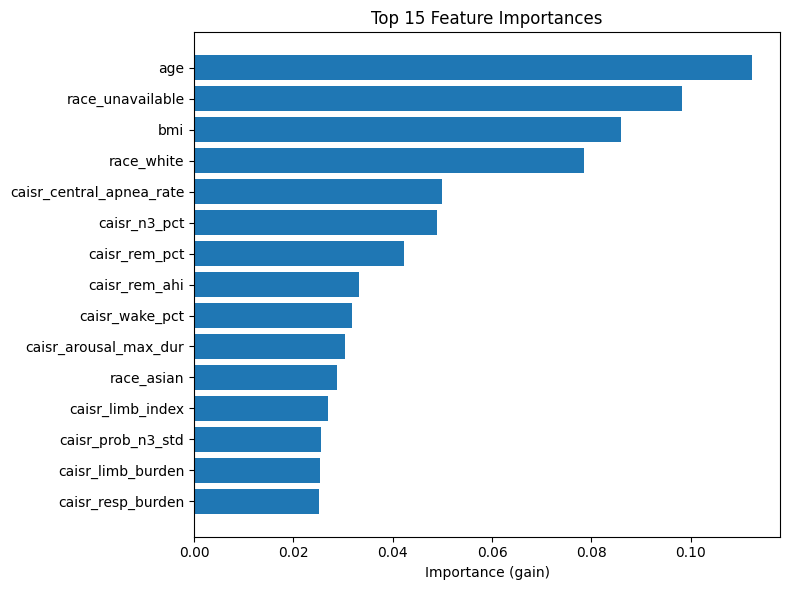

Saved /kaggle/working/top15_feature_importances.png


In [33]:
# Cell 10b — Top-15 feature importances from best classifier

if RUN_XGB and RUN_TABULAR and len(feature_matrix) > 0 and "final_model" in globals():
    importances = final_model.feature_importances_
    feat_imp_df = pd.DataFrame({
        "feature": FEATURE_NAMES,
        "importance": importances,
    }).sort_values("importance", ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(feat_imp_df["feature"][::-1], feat_imp_df["importance"][::-1])
    ax.set_xlabel("Importance (gain)")
    ax.set_title("Top 15 Feature Importances")
    plt.tight_layout()
    plt.savefig(FEATURE_IMPORTANCE_IMG, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {FEATURE_IMPORTANCE_IMG}")
else:
    print("Skipped feature importance plot (no trained model)")

In [34]:
# Cell 11 — SleepFM channel map (standard name -> canonical name + modality)

# Priority order within each modality (first available wins up to cap)
SLEEPFM_MODALITY_PRIORITY = {
    "BAS": ["f3-m2", "f4-m1", "c3-m2", "c4-m1", "o1-m2", "o2-m1", "e1-m2", "e2-m1"],
    "EKG": ["ecg", "ekg"],
    "EMG": ["chin1-chin2", "chin", "lat", "rat"],
    "RESP": ["chest", "abd", "ptaf", "airflow", "spo2", "sao2", "hr"],
}

# Our standardized name -> (SleepFM canonical dataset name, modality)
SLEEPFM_CHANNEL_MAP = {
    "f3-m2": ("F3-M2", "BAS"),
    "f4-m1": ("F4-M1", "BAS"),
    "c3-m2": ("C3-M2", "BAS"),
    "c4-m1": ("C4-M1", "BAS"),
    "o1-m2": ("O1-M2", "BAS"),
    "o2-m1": ("O2-M1", "BAS"),
    "e1-m2": ("E1-M2", "BAS"),
    "e2-m1": ("E2-M1", "BAS"),
    "ecg": ("ECG", "EKG"),
    "ekg": ("ECG", "EKG"),
    "chin1-chin2": ("Chin1-Chin2", "EMG"),
    "chin": ("Chin", "EMG"),
    "lat": ("Leg 1", "EMG"),
    "rat": ("Leg 2", "EMG"),
    "chest": ("Chest", "RESP"),
    "abd": ("Abd", "RESP"),
    "ptaf": ("Nasal Pressure", "RESP"),
    "airflow": ("Airflow", "RESP"),
    "spo2": ("SpO2", "RESP"),
    "sao2": ("SpO2", "RESP"),
    "hr": ("HR", "RESP"),
}

# Excluded: cflow, cpres (CPAP therapy — not in SleepFM RESP vocabulary)


def select_sleepfm_channels(record: PhysiologicalRecord) -> Tuple[Dict[str, Tuple[np.ndarray, float]], dict]:
    """Return {canonical_name: (signal, native_fs)} and selection meta."""
    selected: Dict[str, Tuple[np.ndarray, float]] = {}
    meta = {"by_modality": {m: [] for m in SLEEPFM_MODALITIES}, "skipped": []}
    counts = {m: 0 for m in SLEEPFM_MODALITIES}

    for modality in SLEEPFM_MODALITIES:
        cap = SLEEPFM_CHANNEL_CAPS[modality]
        for std_name in SLEEPFM_MODALITY_PRIORITY.get(modality, []):
            if counts[modality] >= cap:
                break
            if not record.has(std_name):
                continue
            if std_name not in SLEEPFM_CHANNEL_MAP:
                meta["skipped"].append(f"{std_name}: not in SLEEPFM_CHANNEL_MAP")
                continue
            canonical, mod = SLEEPFM_CHANNEL_MAP[std_name]
            if mod != modality:
                continue
            ch = record.get(std_name)
            if canonical in selected:
                continue
            selected[canonical] = (ch.data.astype(np.float64), float(ch.fs_hz))
            meta["by_modality"][modality].append(canonical)
            counts[modality] += 1

    return selected, meta


print("Cell 11: SleepFM channel map OK")


Cell 11: SleepFM channel map OK


In [35]:
# Cell 12 — SleepFM preprocessing contract

def safe_standardize(signal: np.ndarray) -> np.ndarray:
    mean = np.mean(signal)
    std = np.std(signal)
    if std == 0:
        return signal - mean
    return (signal - mean) / std


def filter_signal_antialias(signal: np.ndarray, sample_rate: float, target_rate: float) -> np.ndarray:
    nyquist = sample_rate / 2.0
    cutoff = min(target_rate / 2.0, nyquist)
    normalized_cutoff = cutoff / nyquist
    b, a = butter(4, normalized_cutoff, btype="low", analog=False)
    return filtfilt(b, a, signal)


def resample_to_sleepfm(signal: np.ndarray, native_fs: float, target_fs: int = SLEEPFM_SAMPLING_FREQ) -> np.ndarray:
    if len(signal) == 0:
        return np.array([], dtype=np.float32)
    duration = len(signal) / native_fs
    if native_fs > target_fs:
        signal = filter_signal_antialias(signal, native_fs, target_fs)
    new_count = int(duration * target_fs)
    if new_count <= 0:
        return np.array([], dtype=np.float32)
    original_time = np.linspace(0, duration, num=len(signal), endpoint=False)
    new_time = np.linspace(0, duration, num=new_count, endpoint=False)
    return np.interp(new_time, original_time, signal).astype(np.float64)


def preprocess_record_for_sleepfm(record: PhysiologicalRecord) -> Tuple[Dict[str, np.ndarray], dict]:
    """
    Returns (channels_out, meta) where channels_out maps SleepFM canonical channel name
    -> float32 array at 128 Hz, z-scored, truncated to whole 640-sample tokens.
    """
    raw_selected, sel_meta = select_sleepfm_channels(record)
    channels_out: Dict[str, np.ndarray] = {}
    channel_meta = []
    dropped = list(sel_meta.get("skipped", []))

    for canonical, (sig, native_fs) in raw_selected.items():
        try:
            resampled = resample_to_sleepfm(sig, native_fs)
            standardized = safe_standardize(resampled)
            if np.isnan(standardized).any() or np.isinf(standardized).any():
                dropped.append(f"{canonical}: NaN/inf after standardize")
                continue
            n_tokens = len(standardized) // SLEEPFM_PATCH_SIZE
            if n_tokens == 0:
                dropped.append(f"{canonical}: too short for one token")
                continue
            truncated = standardized[: n_tokens * SLEEPFM_PATCH_SIZE].astype(np.float32)
            channels_out[canonical] = truncated
            channel_meta.append({
                "name": canonical,
                "native_fs": native_fs,
                "n_tokens": n_tokens,
                "duration_min": round(len(truncated) / SLEEPFM_SAMPLING_FREQ / 60.0, 2),
            })
        except Exception as e:
            dropped.append(f"{canonical}: {e}")

    n_tokens_min = min((m["n_tokens"] for m in channel_meta), default=0)
    meta = {
        "by_modality": sel_meta["by_modality"],
        "channel_meta": channel_meta,
        "dropped": dropped,
        "n_channels": len(channels_out),
        "n_tokens_min": n_tokens_min,
        "duration_min": round(n_tokens_min * SLEEPFM_TOKEN_SECONDS / 60.0, 2) if n_tokens_min else 0.0,
    }
    return channels_out, meta


print("Cell 12: SleepFM preprocessing OK")


Cell 12: SleepFM preprocessing OK


In [36]:
# Cell 13 — HDF5 writer + batch preprocessing loop

def write_sleepfm_hdf5(channels_out: Dict[str, np.ndarray], out_path: str) -> None:
    with h5py.File(out_path, "w") as hdf:
        used_names = set()
        for name, sig in channels_out.items():
            unique = name
            i = 1
            while unique in used_names:
                unique = f"{name}_{i}"
                i += 1
            used_names.add(unique)
            hdf.create_dataset(
                unique,
                data=sig.astype(np.float16),
                dtype="float16",
                chunks=(SLEEPFM_CHUNK_SAMPLES,),
                compression="gzip",
            )


manifest_rows = []
n_hdf5_ok = n_hdf5_skip = n_hdf5_err = 0

if RUN_SLEEPFM_PREP:
    iterator = cohort_df.iterrows()
    if VERBOSE:
        iterator = tqdm(list(iterator), desc="SleepFM HDF5 prep", unit="record")

    for _, row in iterator:
        patient_id = row[HEADERS["bids_folder"]]
        site_id = row[HEADERS["site_id"]]
        session_id = row[HEADERS["session_id"]]
        hdf5_path = build_hdf5_path(patient_id, session_id)

        if os.path.exists(hdf5_path):
            n_hdf5_skip += 1
            manifest_rows.append({
                "BidsFolder": patient_id,
                "SessionID": session_id,
                "SiteID": site_id,
                "hdf5_path": hdf5_path,
                "status": "skipped_exists",
            })
            continue

        phys_path = build_physio_path(site_id, patient_id, session_id)
        if not os.path.exists(phys_path):
            n_hdf5_err += 1
            manifest_rows.append({
                "BidsFolder": patient_id,
                "SessionID": session_id,
                "SiteID": site_id,
                "hdf5_path": "",
                "status": "missing_physio_edf",
            })
            continue

        try:
            rel_path = build_physio_rel_path(site_id, patient_id, session_id)
            record = load_physiological_record(phys_path, rel_path)
            channels_out, prep_meta = preprocess_record_for_sleepfm(record)
            if len(channels_out) == 0:
                n_hdf5_err += 1
                manifest_rows.append({
                    "BidsFolder": patient_id,
                    "SessionID": session_id,
                    "SiteID": site_id,
                    "hdf5_path": "",
                    "status": "no_channels_after_prep",
                    "dropped": "; ".join(prep_meta.get("dropped", [])),
                })
                del record
                continue

            write_sleepfm_hdf5(channels_out, hdf5_path)
            label = load_diagnoses(demo_csv, patient_id)
            manifest_rows.append({
                "BidsFolder": patient_id,
                "SessionID": session_id,
                "SiteID": site_id,
                "hdf5_path": hdf5_path,
                "status": "ok",
                "Cognitive_Impairment": label,
                "n_channels": prep_meta["n_channels"],
                "n_tokens": prep_meta["n_tokens_min"],
                "duration_min": prep_meta["duration_min"],
                "n_BAS": len(prep_meta["by_modality"].get("BAS", [])),
                "n_RESP": len(prep_meta["by_modality"].get("RESP", [])),
                "n_EKG": len(prep_meta["by_modality"].get("EKG", [])),
                "n_EMG": len(prep_meta["by_modality"].get("EMG", [])),
                "dropped": "; ".join(prep_meta.get("dropped", [])),
            })
            n_hdf5_ok += 1
            del record, channels_out
        except Exception as e:
            n_hdf5_err += 1
            manifest_rows.append({
                "BidsFolder": patient_id,
                "SessionID": session_id,
                "SiteID": site_id,
                "hdf5_path": "",
                "status": f"error: {e}",
            })
            if VERBOSE:
                tqdm.write(f"  !!! HDF5 error {patient_id}: {e}")

    print(f"\nSleepFM HDF5: ok={n_hdf5_ok}, skipped={n_hdf5_skip}, errors={n_hdf5_err}")
else:
    print("RUN_SLEEPFM_PREP=False — skipped HDF5 preprocessing")


RUN_SLEEPFM_PREP=False — skipped HDF5 preprocessing


In [37]:
# Cell 14 — Contract validation + sleepfm_manifest.csv

def validate_sleepfm_hdf5(hdf5_path: str) -> dict:
    results = {"path": hdf5_path, "passed": True, "issues": [], "modality_counts": {m: 0 for m in SLEEPFM_MODALITIES}}
    canonical_to_mod = {v[0]: v[1] for v in SLEEPFM_CHANNEL_MAP.values()}
    # rebuild lookup including aliases
    name_to_mod = {}
    for std, (canon, mod) in SLEEPFM_CHANNEL_MAP.items():
        name_to_mod[canon] = mod
        name_to_mod[canon.lower()] = mod

    with h5py.File(hdf5_path, "r") as hdf:
        for ds_name in hdf.keys():
            ds = hdf[ds_name]
            data = ds[()]
            mod = name_to_mod.get(ds_name, name_to_mod.get(ds_name.split("_")[0], None))
            if mod:
                results["modality_counts"][mod] += 1

            if len(data) % SLEEPFM_PATCH_SIZE != 0:
                results["passed"] = False
                results["issues"].append(f"{ds_name}: length {len(data)} not multiple of {SLEEPFM_PATCH_SIZE}")
            if ds.dtype != np.float16:
                results["passed"] = False
                results["issues"].append(f"{ds_name}: dtype {ds.dtype} != float16")
            if np.isnan(data).any() or np.isinf(data).any():
                results["passed"] = False
                results["issues"].append(f"{ds_name}: contains NaN/inf")
            arr = data.astype(np.float64)
            mu, sd = np.mean(arr), np.std(arr)
            if sd > 1e-6 and (abs(mu) > 0.05 or abs(sd - 1.0) > 0.15):
                results["issues"].append(
                    f"{ds_name}: mean={mu:.3f} std={sd:.3f} (expected ~0, ~1)"
                )

    for mod in SLEEPFM_MODALITIES:
        if results["modality_counts"][mod] == 0:
            results["issues"].append(f"missing modality {mod}")
            results["passed"] = False

    return results


if manifest_rows:
    manifest_df = pd.DataFrame(manifest_rows)
    manifest_df.to_csv(SLEEPFM_MANIFEST, index=False)
    print(f"Saved {SLEEPFM_MANIFEST} ({len(manifest_df)} rows)")

    ok_paths = manifest_df.loc[manifest_df["status"] == "ok", "hdf5_path"].dropna().tolist()
    if ok_paths:
        sample_path = ok_paths[0]
        val = validate_sleepfm_hdf5(sample_path)
        print(f"\n=== Contract validation (sample: {os.path.basename(sample_path)}) ===")
        print(f"  Passed: {val['passed']}")
        print(f"  Modality counts: {val['modality_counts']}")
        if val["issues"]:
            print("  Issues:")
            for issue in val["issues"][:10]:
                print(f"    - {issue}")
        if not val["passed"]:
            raise RuntimeError("SleepFM contract validation failed on sample HDF5")
else:
    print("No manifest rows to validate")


No manifest rows to validate


In [38]:
# Cell 15 — Optional physiological exploration (gated)

if EXPLORE_PHYSIO:
    from IPython.display import display

    record_paths = find_records(phys_folder, file_extension=".edf")
    print(f"Found {len(record_paths)} physiological EDF records")

    example_rel_path = record_paths[0]
    example_edf_path = os.path.join(phys_folder, example_rel_path + ".edf")
    explore_record = load_physiological_record(example_edf_path, example_rel_path)

    print(f"\nExample: site={explore_record.site_id}, patient={explore_record.patient_id}")
    display(explore_record.catalog())

    MAX_EXPLORE = 5
    summaries = []
    for rel_path in record_paths[:MAX_EXPLORE]:
        edf_path = os.path.join(phys_folder, rel_path + ".edf")
        rec = load_physiological_record(edf_path, rel_path)
        cat = rec.catalog()
        cat["site_id"] = rec.site_id
        cat["patient_id"] = rec.patient_id
        summaries.append(cat)
    if summaries:
        display(pd.concat(summaries, ignore_index=True))
else:
    print("EXPLORE_PHYSIO=False — skipped channel catalog demo")


EXPLORE_PHYSIO=False — skipped channel catalog demo
